In [3]:
# 02 Prepare Inputs
# Goal: create a masked 3-band RGB GeoTIFF from the source TIFF and resample it to 0.6 m.


In [5]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_origin


In [7]:
image_path = Path(r"/Users/rgcappl037/Desktop/CHMv2/IMG_PHR1A_PMS_202508271555298_ORT_b24bf281-b6fd-48dc-c86f-f97e23fc09aa_R1C1.TIF")

project_root = Path("/Users/rgcappl037/Documents/New project/electric-pole-analysis")
intermediate_dir = project_root / "data" / "intermediate"
intermediate_dir.mkdir(parents=True, exist_ok=True)

rgb_masked_path = intermediate_dir / "rgb3_alpha_nodata255.tif"
resampled_path = intermediate_dir / "rgb3_alpha_nodata255_res060.tif"

print("Input exists:", image_path.exists())
print("Intermediate dir:", intermediate_dir)
print("Masked RGB output:", rgb_masked_path)
print("Resampled output:", resampled_path)


Input exists: True
Intermediate dir: /Users/rgcappl037/Documents/New project/electric-pole-analysis/data/intermediate
Masked RGB output: /Users/rgcappl037/Documents/New project/electric-pole-analysis/data/intermediate/rgb3_alpha_nodata255.tif
Resampled output: /Users/rgcappl037/Documents/New project/electric-pole-analysis/data/intermediate/rgb3_alpha_nodata255_res060.tif


In [9]:
with rasterio.open(image_path) as src:
    print("Driver:", src.driver)
    print("Width x Height:", src.width, "x", src.height)
    print("Band count:", src.count)
    print("Dtypes:", src.dtypes)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)
    print("Nodata:", src.nodata)
    print("Color interpretation:", src.colorinterp)


Driver: GTiff
Width x Height: 2632 x 2796
Band count: 4
Dtypes: ('uint8', 'uint8', 'uint8', 'uint8')
CRS: EPSG:32618
Resolution: (0.5, 0.5)
Bounds: BoundingBox(left=320966.0, bottom=4315754.0, right=322282.0, top=4317152.0)
Nodata: None
Color interpretation: (<ColorInterp.red: 3>, <ColorInterp.green: 4>, <ColorInterp.blue: 5>, <ColorInterp.undefined: 0>)


In [11]:
with rasterio.open(image_path) as src:
    rgb = src.read([1, 2, 3])
    alpha = src.read(4)
    meta = src.meta.copy()

valid_mask = alpha > 0
rgb_out = rgb.copy()

for b in range(3):
    rgb_out[b][~valid_mask] = 255

meta.update({
    "count": 3,
    "dtype": "uint8",
    "nodata": 255
})

with rasterio.open(rgb_masked_path, "w", **meta) as dst:
    dst.write(rgb_out)
    dst.write_mask((valid_mask.astype(np.uint8) * 255))

print("Saved masked RGB:", rgb_masked_path)


Saved masked RGB: /Users/rgcappl037/Documents/New project/electric-pole-analysis/data/intermediate/rgb3_alpha_nodata255.tif


In [13]:
with rasterio.open(rgb_masked_path) as src:
    print("Band count:", src.count)
    print("Dtypes:", src.dtypes)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Nodata:", src.nodata)
    print("Width x Height:", src.width, src.height)


Band count: 3
Dtypes: ('uint8', 'uint8', 'uint8')
CRS: EPSG:32618
Resolution: (0.5, 0.5)
Nodata: 255.0
Width x Height: 2632 2796


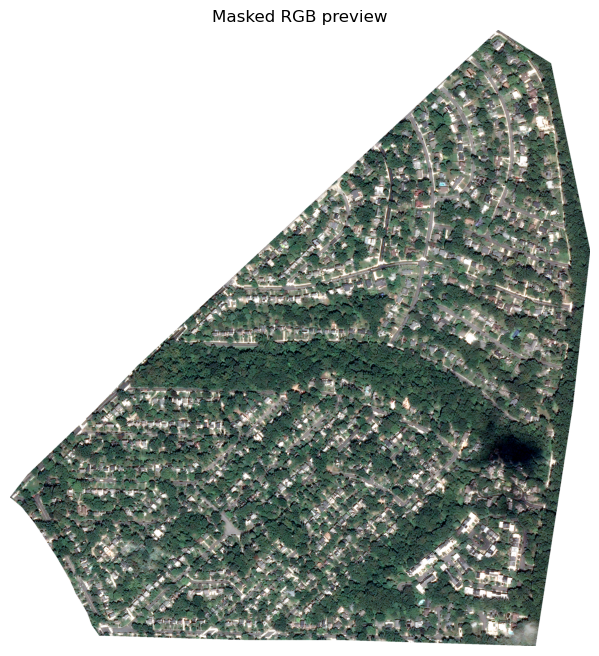

In [15]:
with rasterio.open(rgb_masked_path) as src:
    rgb = src.read([1, 2, 3])

rgb_hwc = np.moveaxis(rgb, 0, -1).astype(np.float32)

for b in range(3):
    valid = rgb_hwc[..., b] != 255
    if valid.any():
        p2, p98 = np.percentile(rgb_hwc[..., b][valid], (2, 98))
        if p98 > p2:
            rgb_hwc[..., b] = np.clip((rgb_hwc[..., b] - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_hwc)
plt.title("Masked RGB preview")
plt.axis("off")
plt.show()


In [17]:
target_res = 0.6

with rasterio.open(rgb_masked_path) as src:
    left, bottom, right, top = src.bounds
    new_width = math.ceil((right - left) / target_res)
    new_height = math.ceil((top - bottom) / target_res)
    new_transform = from_origin(left, top, target_res, target_res)

    meta = src.meta.copy()
    meta.update({
        "width": new_width,
        "height": new_height,
        "transform": new_transform,
        "count": 3,
        "dtype": "uint8",
        "nodata": 255
    })

    with rasterio.open(resampled_path, "w", **meta) as dst:
        for i in range(1, 4):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=src.crs,
                src_nodata=255,
                dst_nodata=255,
                resampling=Resampling.bilinear
            )

        mask = np.zeros((new_height, new_width), dtype=np.uint8)
        reproject(
            source=src.read_masks(1),
            destination=mask,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=new_transform,
            dst_crs=src.crs,
            resampling=Resampling.nearest
        )
        dst.write_mask(mask)

print("Saved resampled RGB:", resampled_path)


Saved resampled RGB: /Users/rgcappl037/Documents/New project/electric-pole-analysis/data/intermediate/rgb3_alpha_nodata255_res060.tif


In [19]:
with rasterio.open(resampled_path) as src:
    print("Band count:", src.count)
    print("Dtypes:", src.dtypes)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Nodata:", src.nodata)
    print("Width x Height:", src.width, src.height)


Band count: 3
Dtypes: ('uint8', 'uint8', 'uint8')
CRS: EPSG:32618
Resolution: (0.6, 0.6)
Nodata: 255.0
Width x Height: 2194 2330


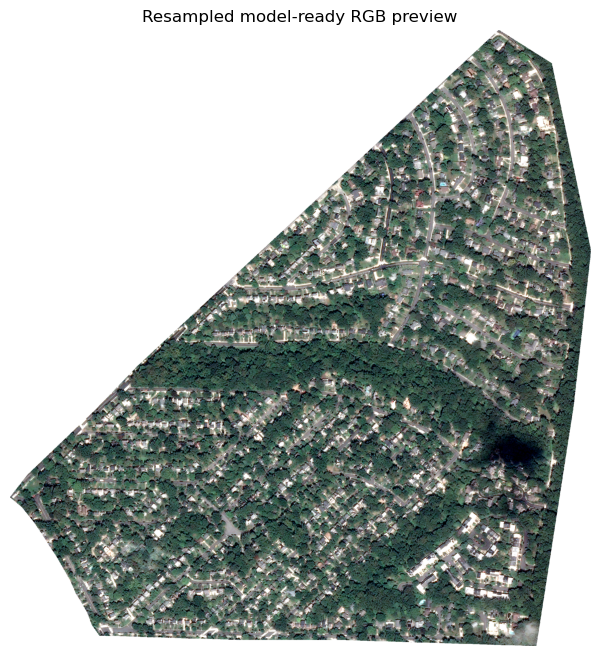

In [21]:
with rasterio.open(resampled_path) as src:
    rgb = src.read([1, 2, 3])

rgb_hwc = np.moveaxis(rgb, 0, -1).astype(np.float32)

for b in range(3):
    valid = rgb_hwc[..., b] != 255
    if valid.any():
        p2, p98 = np.percentile(rgb_hwc[..., b][valid], (2, 98))
        if p98 > p2:
            rgb_hwc[..., b] = np.clip((rgb_hwc[..., b] - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_hwc)
plt.title("Resampled model-ready RGB preview")
plt.axis("off")
plt.show()


In [23]:
print("Masked RGB file:", rgb_masked_path)
print("Resampled model-ready file:", resampled_path)


Masked RGB file: /Users/rgcappl037/Documents/New project/electric-pole-analysis/data/intermediate/rgb3_alpha_nodata255.tif
Resampled model-ready file: /Users/rgcappl037/Documents/New project/electric-pole-analysis/data/intermediate/rgb3_alpha_nodata255_res060.tif


In [25]:
from pathlib import Path

project_root = Path("/Users/rgcappl037/Documents/New project/electric-pole-analysis")
intermediate_dir = project_root / "data" / "intermediate"

expected_files = [
    intermediate_dir / "rgb3_alpha_nodata255.tif",
    intermediate_dir / "rgb3_alpha_nodata255_res060.tif",
    intermediate_dir / "rgb3_alpha_native.tif",
    intermediate_dir / "rgb3_alpha_native_res060.tif",
]

print("Intermediate directory:", intermediate_dir)
print()

for path in expected_files:
    print(path.name, "->", path.exists())


Intermediate directory: /Users/rgcappl037/Documents/New project/electric-pole-analysis/data/intermediate

rgb3_alpha_nodata255.tif -> True
rgb3_alpha_nodata255_res060.tif -> True
rgb3_alpha_native.tif -> False
rgb3_alpha_native_res060.tif -> False


In [27]:
from pathlib import Path
import numpy as np
import rasterio

image_path = Path(r"/Users/rgcappl037/Desktop/CHMv2/IMG_PHR1A_PMS_202508271555298_ORT_b24bf281-b6fd-48dc-c86f-f97e23fc09aa_R1C1.TIF")

project_root = Path("/Users/rgcappl037/Documents/New project/electric-pole-analysis")
intermediate_dir = project_root / "data" / "intermediate"
intermediate_dir.mkdir(parents=True, exist_ok=True)

rgb3_alpha_native_path = intermediate_dir / "rgb3_alpha_native.tif"

with rasterio.open(image_path) as src:
    rgb = src.read([1, 2, 3])
    alpha = src.read(4)
    meta = src.meta.copy()

valid_mask = alpha > 0

meta.update({
    "count": 3,
    "dtype": "uint8",
    "nodata": None
})

with rasterio.open(rgb3_alpha_native_path, "w", **meta) as dst:
    dst.write(rgb)
    dst.write_mask((valid_mask.astype(np.uint8) * 255))

print("Saved:", rgb3_alpha_native_path)


Saved: /Users/rgcappl037/Documents/New project/electric-pole-analysis/data/intermediate/rgb3_alpha_native.tif


In [29]:
with rasterio.open(rgb3_alpha_native_path) as src:
    print("Band count:", src.count)
    print("Dtypes:", src.dtypes)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Nodata:", src.nodata)
    print("Width x Height:", src.width, src.height)


Band count: 3
Dtypes: ('uint8', 'uint8', 'uint8')
CRS: EPSG:32618
Resolution: (0.5, 0.5)
Nodata: None
Width x Height: 2632 2796
